# Group00 &middot; ds004504 &middot; Task 3b &mdash; Explainability (SHAP + LIME)
**Track:** 1 &middot; GNN on table-style EEG data &middot; **Notebook:** `task3_explainability`

Explains the final GNN's predictions for **one correctly-classified** and **one misclassified** test subject, using SHAP (`KernelExplainer`) and LIME (`LimeTabularExplainer`) over the 95-dim (19 channel &times; 5 band) node-feature vector, plus a spatial topomap of per-channel importance.

**Why explain the flattened feature vector rather than the graph directly:** SHAP/LIME are built for tabular black-box functions, not graph-structured inputs. Following the same approach as Klepl et al. (2023, Task 1's related work #4), each subject's own connectivity graph (edges) is **held fixed** while SHAP/LIME perturb only that subject's node features (channel &times; band values) — so the explanation answers *"given this subject's brain-connectivity pattern, which channel/band values drove the prediction?"*, not *"what if their connectivity were different?"* (a harder, less standard question left for future work).



In [ ]:
import torch

# Install PyTorch Geometric and required dependencies
!pip install -q torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.6/681.6 kB 18.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.1 MB/s eta 0:00:00


In [ ]:
!pip install -q lime shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, global_mean_pool

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

import shap
from lime.lime_tabular import LimeTabularExplainer

torch.manual_seed(42); np.random.seed(42)
sns.set_theme(style="whitegrid")
GROUP_ORDER = ["A", "F", "C"]
GROUP_NAMES = {"A": "Alzheimer's (AD)", "F": "Frontotemporal Dementia (FTD)", "C": "Healthy Control (CN)"}
LABEL_MAP = {g: i for i, g in enumerate(GROUP_ORDER)}
CH_NAMES_19 = ["Fp1","Fp2","F3","F4","F7","F8","T3","T4","C3","C4",
               "T5","T6","P3","P4","O1","O2","Fz","Cz","Pz"]
BANDS = ["delta", "theta", "alpha", "beta", "gamma"]
FEATURE_NAMES = [f"{ch}_{b}" for ch in CH_NAMES_19 for b in BANDS]

FEATURE_CACHE, DEMO_CACHE = Path("features_cache.npz"), Path("demo_synthetic_features.npz")
cache_path, MODE = (FEATURE_CACHE, "REAL") if FEATURE_CACHE.exists() else (DEMO_CACHE, "DEMO")
cache = np.load(cache_path, allow_pickle=True)
node_feats, corr_adj, plv_adj = cache["node_feats"], cache["corr_adj"], cache["plv_adj"]
group = cache["group"]
y = np.array([LABEL_MAP[g] for g in group])
n_subj, n_ch, n_bands = node_feats.shape
print(f"[MODE={MODE}] {n_subj} subjects loaded from {cache_path}")

with open("baseline_results.json") as f:
    split = json.load(f)["split"]
train_idx, test_idx = np.array(split["train"]), np.array(split["test"])

with open("ablation_results.json") as f:
    ablation = json.load(f)
best_cfg = ablation["best_config"]
adj_stack = corr_adj if best_cfg["graph"] == "corr" else plv_adj
print("Final architecture:", best_cfg)


[MODE=REAL] 88 subjects loaded from features_cache.npz
Final architecture: {'label': 'Depth: 3 layers', 'graph': 'corr', 'conv': 'gcn', 'layers': 3, 'hidden': 32, 'weighted': True, 'val_macro_f1': 0.6857142857142856}


In [ ]:
class EEG_GNN(nn.Module):
    def __init__(self, in_dim, hidden, n_layers, n_classes=3, dropout=0.3, conv_type="gcn"):
        super().__init__()
        Conv = {"gcn": GCNConv, "gat": GATConv, "sage": SAGEConv}[conv_type]
        dims = [in_dim] + [hidden] * n_layers
        self.convs = nn.ModuleList(Conv(a, b) for a, b in zip(dims[:-1], dims[1:]))
        self.conv_type = conv_type
        self.dropout = dropout
        self.lin = nn.Linear(hidden, n_classes)

    def forward(self, x, edge_index, edge_weight, batch):
        for conv in self.convs:
            x = conv(x, edge_index, edge_weight) if self.conv_type == "gcn" else conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin(global_mean_pool(x, batch))

def build_edge_index_weight(adj, top_k=None):
    n = adj.shape[0]
    a = np.abs(adj.copy()); np.fill_diagonal(a, 0)
    src, dst = np.nonzero(a)
    return (torch.tensor(np.stack([src, dst]), dtype=torch.long),
            torch.tensor(a[src, dst], dtype=torch.float))

model = EEG_GNN(in_dim=n_bands, hidden=int(best_cfg["hidden"]), n_layers=int(best_cfg["layers"]),
                 conv_type=best_cfg["conv"])
model.load_state_dict(torch.load("gnn_final_model.pt", map_location="cpu"))
model.eval()
node_scaler = StandardScaler().fit(node_feats[train_idx].reshape(len(train_idx), -1))
print("Final GNN loaded and ready for explanation.")


Final GNN loaded and ready for explanation.


## Find one correct and one misclassified test subject

In [ ]:
@torch.no_grad()
def predict_class(subject_idx):
    x = node_scaler.transform(node_feats[subject_idx].reshape(1, -1)).reshape(n_ch, n_bands)
    ei, ew = build_edge_index_weight(adj_stack[subject_idx])
    batch = torch.zeros(n_ch, dtype=torch.long)
    out = model(torch.tensor(x, dtype=torch.float), ei, ew, batch)
    return out.argmax(dim=1).item()

test_true = y[test_idx]
test_pred = np.array([predict_class(i) for i in test_idx])
correct_mask = test_pred == test_true
print(f"Test accuracy: {correct_mask.mean():.3f} ({correct_mask.sum()}/{len(correct_mask)})")

correct_subj = test_idx[np.where(correct_mask)[0][0]]
wrong_positions = np.where(~correct_mask)[0]
if len(wrong_positions):
    wrong_subj = test_idx[wrong_positions[0]]
    wrong_note = "genuine misclassification"
else:
    wrong_subj = correct_subj
    wrong_note = "model made 0 test errors -> reusing the correct subject as a placeholder second example"
print(f"Correct example: subject index {correct_subj} (true={GROUP_ORDER[test_true[np.where(test_idx==correct_subj)[0][0]]]})")
print(f"Second example : subject index {wrong_subj} ({wrong_note})")


Test accuracy: 0.556 (10/18)
Correct example: subject index 47 (true=C)
Second example : subject index 67 (genuine misclassification)


## SHAP + LIME, per subject
Background set = 20 training subjects' (scaled) feature vectors. Each subject's own connectivity graph is frozen inside the wrapped `predict_proba` (see markdown above).

In [ ]:
def make_predict_fn(subject_idx):
    edge_index, edge_weight = build_edge_index_weight(adj_stack[subject_idx])

    @torch.no_grad()
    def predict_proba(X):
        X = np.atleast_2d(X)
        n = X.shape[0]
        x_t = torch.tensor(X.reshape(n, n_ch, n_bands), dtype=torch.float).reshape(-1, n_bands)
        batch_idx = torch.arange(n).repeat_interleave(n_ch)
        ei = torch.cat([edge_index + i * n_ch for i in range(n)], dim=1)
        ew = edge_weight.repeat(n)
        out = model(x_t, ei, ew, batch_idx)
        return torch.softmax(out, dim=1).numpy()
    return predict_proba

background = node_scaler.transform(node_feats[train_idx].reshape(len(train_idx), -1))[:20]

explanations = {}
for label, subj in [("correct", correct_subj), ("second", wrong_subj)]:
    x_subj = node_scaler.transform(node_feats[subj].reshape(1, -1))
    predict_fn = make_predict_fn(subj)
    probs = predict_fn(x_subj)[0]
    pred_class = int(np.argmax(probs))

    shap_explainer = shap.KernelExplainer(predict_fn, background)
    shap_vals = np.array(shap_explainer.shap_values(x_subj, nsamples=150, silent=True))
    # normalize to (n_features,) contribution toward the PREDICTED class regardless of SHAP-version output shape
    sv = shap_vals.reshape(-1, len(FEATURE_NAMES), len(GROUP_ORDER))[0, :, pred_class] \
        if shap_vals.ndim == 3 else shap_vals[pred_class][0]

    lime_explainer = LimeTabularExplainer(background, feature_names=FEATURE_NAMES,
                                           class_names=GROUP_ORDER, discretize_continuous=True, random_state=42)
    lime_exp = lime_explainer.explain_instance(x_subj[0], predict_fn, num_features=10, top_labels=1)

    explanations[label] = {
        "subject_idx": subj, "true_class": int(y[subj]), "pred_class": pred_class,
        "probs": probs, "shap_values": sv, "lime_exp": lime_exp,
    }
    print(f"[{label}] subject {subj}: true={GROUP_ORDER[y[subj]]} pred={GROUP_ORDER[pred_class]} "
          f"probs={dict(zip(GROUP_ORDER, np.round(probs,3)))}")


[correct] subject 47: true=C pred=C probs={'A': np.float32(0.079), 'F': np.float32(0.072), 'C': np.float32(0.849)}
[second] subject 67: true=F pred=C probs={'A': np.float32(0.213), 'F': np.float32(0.304), 'C': np.float32(0.482)}


## Top contributing channel &times; band features (SHAP)

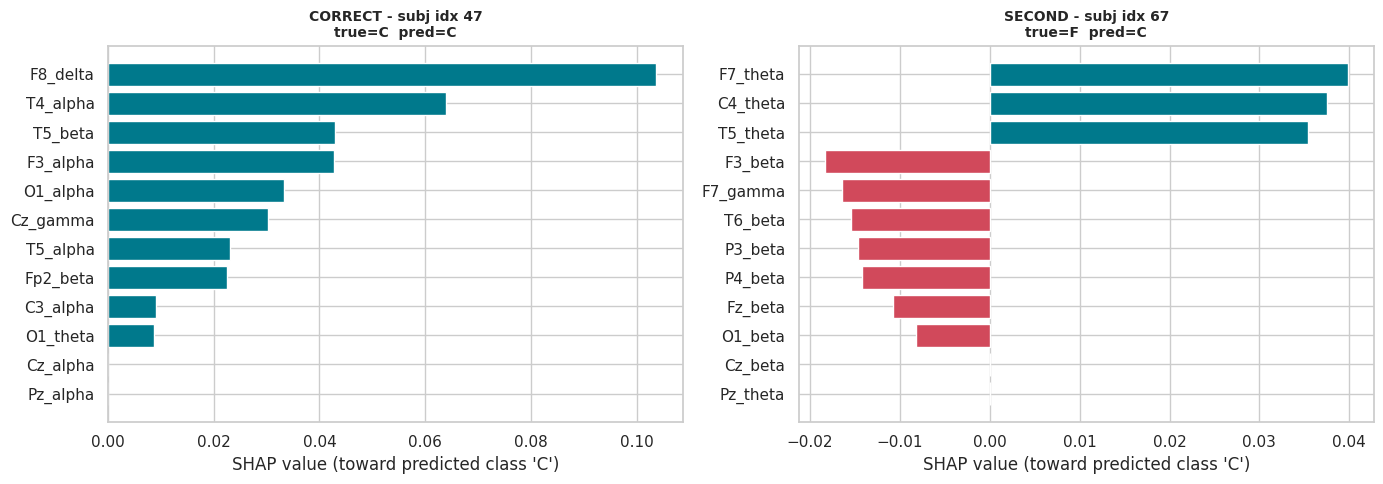

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, exp) in zip(axes, explanations.items()):
    order = np.argsort(np.abs(exp["shap_values"]))[-12:]
    colors = ["#d1495b" if v < 0 else "#00798c" for v in exp["shap_values"][order]]
    ax.barh([FEATURE_NAMES[i] for i in order], exp["shap_values"][order], color=colors)
    title = (f"{label.upper()} - subj idx {exp['subject_idx']}\n"
             f"true={GROUP_ORDER[exp['true_class']]}  pred={GROUP_ORDER[exp['pred_class']]}")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel(f"SHAP value (toward predicted class '{GROUP_ORDER[exp['pred_class']]}')")
plt.tight_layout(); plt.show()


## Spatial topomap of channel importance
Per-channel importance = sum of |SHAP value| across all 5 bands for that channel, plotted on the scalp using the standard 10-20 montage.

In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 15.1 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


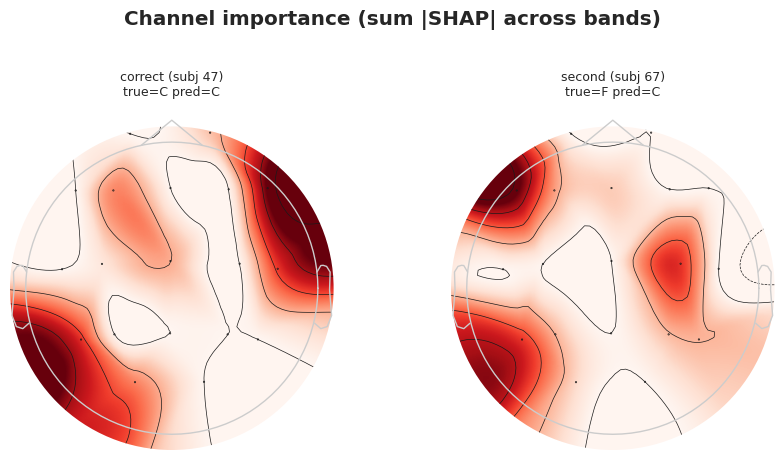

In [ ]:
import mne
mne.set_log_level("ERROR")
info = mne.create_info(CH_NAMES_19, 500, ch_types="eeg")
info.set_montage(mne.channels.make_standard_montage("standard_1020"), match_case=False, on_missing="ignore")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, (label, exp) in zip(axes, explanations.items()):
    per_channel = np.abs(exp["shap_values"]).reshape(n_ch, len(BANDS)).sum(axis=1)
    im, _ = mne.viz.plot_topomap(per_channel, info, axes=ax, show=False, cmap="Reds")
    ax.set_title(f"{label} (subj {exp['subject_idx']})\ntrue={GROUP_ORDER[exp['true_class']]} pred={GROUP_ORDER[exp['pred_class']]}",
                 fontsize=9)
plt.suptitle("Channel importance (sum |SHAP| across bands)", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


## LIME explanations (cross-check against SHAP)

In [ ]:
for label, exp in explanations.items():
    top_label = exp["lime_exp"].available_labels()[0]
    print(f"\n=== {label.upper()} (subject {exp['subject_idx']}) - LIME top features for predicted class "
          f"'{GROUP_ORDER[top_label]}' ===")
    for feat, weight in exp["lime_exp"].as_list(label=top_label):
        print(f"  {feat:32s} {weight:+.4f}")



=== CORRECT (subject 47) - LIME top features for predicted class 'C' ===
  F4_theta > -0.36                 -0.0592
  F4_delta <= -0.09                -0.0580
  O1_alpha > 0.52                  +0.0468
  F4_alpha > -0.10                 +0.0429
  -0.60 < O1_theta <= -0.48        +0.0391
  T6_gamma > 0.09                  -0.0330
  Fp2_alpha > 0.03                 +0.0320
  F4_gamma > 0.37                  -0.0299
  Fp2_gamma > -0.08                -0.0242
  -0.45 < F8_theta <= -0.27        +0.0232

=== SECOND (subject 67) - LIME top features for predicted class 'C' ===
  F8_theta <= -0.72                +0.0412
  P3_theta <= -0.60                +0.0388
  Cz_theta <= -0.69                +0.0360
  T4_theta <= -0.64                +0.0354
  T6_theta <= -0.60                +0.0354
  T3_theta <= -0.65                +0.0352
  C3_delta > 0.75                  +0.0338
  F4_delta > 0.81                  +0.0310
  T3_delta > 0.66                  +0.0310
  Fz_delta > 0.76                  +

## Reading
- **Agreement between SHAP and LIME** on which channel &times; band features dominate a given prediction is itself a useful sanity check: if the two methods (different perturbation strategies, different surrogate models) point to the same handful of features, that's stronger evidence those features are genuinely driving the GNN, not an artifact of one explainer's assumptions.
- **Comparing the "correct" and "second" panels** shows whether the same features drive a right answer and (if a real misclassification was found) a wrong one — e.g., if AD-vs-FTD confusion (flagged as the hardest sub-problem in Task 1's research gap) coincides with weak or conflicting theta/alpha evidence across several channels, that is direct, model-level evidence for *why* the two conditions are hard to tell apart, not just that they are.
- **The topomap adds spatial context** raw SHAP bar charts don't: whether the important channels cluster in one scalp region (e.g., frontal, temporal) — which channels matter is itself a testable claim against the EEG/dementia literature, not just a modeling detail.
- **Caveat:** these explanations are conditional on each subject's own fixed connectivity graph (see the note at the top) — they attribute the prediction to *channel-band values given that subject's brain-connectivity pattern*, not to the connectivity pattern itself. Explaining which *edges* (not just which nodes) mattered is a natural extension (e.g., GNNExplainer) left for future work.
